In [5]:
from Py_FS.wrapper.population_based.BBA import BBA as FS

import pandas as pd
import numpy as np
import time

In [6]:
import opfython.math.general as g
import opfython.stream.parser as p
import opfython.stream.splitter as s
from opfython.models import SupervisedOPF

In [7]:
df_cis = pd.read_csv('../data/cis_data.csv')
df_cacao = pd.read_csv(r'../data/data_temp/cacao.csv')
df_algarrobo = pd.read_csv(r'../data/data_temp/algarrobo.csv')
covering_array  = np.loadtxt(r'../data/coveringArray.csv', delimiter=",", dtype=int)

df_x_cacao = df_cacao.iloc[:, 1:]
y_cacao = df_cacao.iloc[:, 0:1]
X_cacao = (df_x_cacao-df_x_cacao.min())/(df_x_cacao.max()-df_x_cacao.min())

algarrobo_x = df_algarrobo.loc[:, 'R':'REDVI']
y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
X_algarrobo = (algarrobo_x-algarrobo_x.min())/(algarrobo_x.max()-algarrobo_x.min())

cis_x = df_cis[['X', 'Y', 'X10', 'Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']]
y_cis = df_cis[['Result']]
X_cis = (cis_x-cis_x.min())/(cis_x.max()-cis_x.min())

C:\Users\robma\AppData\Local\Temp\ipykernel_14400\3120085030.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])


BBA ALGARROBO 


************    Please enter the values of the following paramters or press newline for using default values    ************


*****************************************************    Thank You    ******************************************************


                          Iteration - 1


Number of agents: 60

------------- Best Agent ---------------
Fitness: 0.7645000000000001
Number of Features: 9
----------------------------------------

Bat 1 - Fitness: 0.7645000000000001, Number of Features: 9
Bat 2 - Fitness: 0.7645000000000001, Number of Features: 9
Bat 3 - Fitness: 0.7645000000000001, Number of Features: 9
Bat 4 - Fitness: 0.7645000000000001, Number of Features: 9
Bat 5 - Fitness: 0.7645000000000001, Number of Features: 9
Bat 6 - Fitness: 0.7645000000000001, Number of Features: 9
Bat 7 - Fitness: 0.7645000000000001, Number of Features: 9
Bat 8 - Fitness: 0.7645000000000001, Number of Features: 9
Bat 9 - Fitness: 0.7645000000000001, Number of Features: 9
Bat 10 - Fitness:

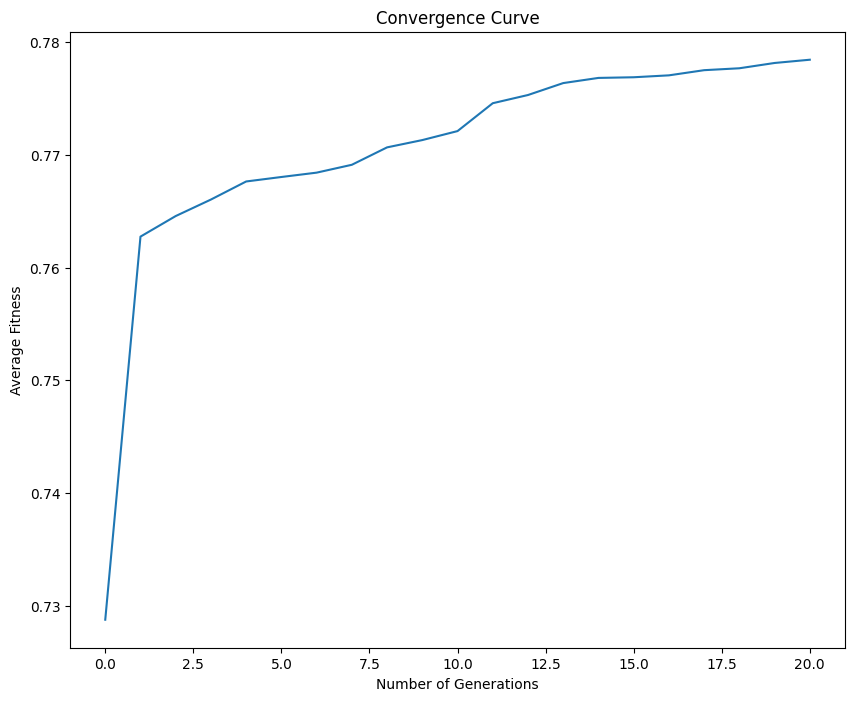


------------- Leader Agent ---------------
Fitness: 0.7818333333333334
Number of Features: 7
----------------------------------------

Processing time: 80.5206651687622 seconds


In [17]:
start_time = time.time()
bba = FS(num_agents=60, max_iter=20, train_data=X_algarrobo, train_label=y_algarrobo,save_conv_graph=True)
results_algarrobo = bba.run()
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

Features Selected Agarrobo

In [18]:
features_selected = []
#['G', 'NIR', 'EXG', 'EXGR', 'NGBDI', 'GBRI.1', 'MGRVI']
header = list(X_algarrobo.columns.values)
for i in range(0, len(header) -1):
  if results_algarrobo.Leader_agent[i] == 1 :
      features_selected.append(header[i])
features_selected

['G', 'NIR', 'EXG', 'NGBDI', 'GBRI.1', 'MGRVI', 'RERVI']

In [11]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score

scores = []
kf = KFold(n_splits=5,shuffle=True, random_state =42)
X = X_algarrobo[['G', 'NIR', 'EXG', 'NGBDI', 'GBRI.1', 'MGRVI', 'RERVI']]

for i, (train_index, test_index) in enumerate(kf.split(X.values)):
   
   x_fold_train = X.values[train_index,:]
   y_fold_train = y_algarrobo.values[train_index]

   x_fold_test =  X.values[test_index,:]
   y_fold_test = y_algarrobo.values[test_index]
   
   clf = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
   clf.fit(x_fold_train, y_fold_train)
   y_pred_fold = clf.predict(x_fold_test)
   score = f1_score(y_fold_test, y_pred_fold,average='macro')
   scores.append(score)

res = np.asarray(scores, dtype=np.float32)
print(f"5-CV Algarrobo OPF mean:{res.mean()} , 5-CV Algarrobo STD:{res.std()}" )

2025-03-30 08:10:40,986 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-30 08:10:40,988 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-30 08:10:40,989 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-30 08:10:40,991 - opfython.core.opf — INFO — Class created.
2025-03-30 08:10:40,992 - opfython.models.supervised — INFO — Class overrided.
2025-03-30 08:10:40,994 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-30 08:10:41,002 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-03-30 08:10:41,589 - opfython.models.supervised — DEBUG — Prototypes: [635, 0, 42, 634, 579, 238, 786, 794, 15, 402, 784, 21, 483, 202, 200, 777, 578, 17, 670, 425, 222, 9, 506, 587, 5, 456, 489, 233, 676, 229, 543, 633, 560, 641, 230, 517, 473, 651, 696, 14, 12, 730, 585, 223, 516, 526, 539, 146, 409, 228, 441, 628, 642, 185, 689, 451, 103, 19, 234, 798, 220, 508, 664, 226, 507, 

BBA CACAO


************    Please enter the values of the following paramters or press newline for using default values    ************


*****************************************************    Thank You    ******************************************************


                          Iteration - 1


Number of agents: 60

------------- Best Agent ---------------
Fitness: 0.8571150476932062
Number of Features: 431
----------------------------------------

Bat 1 - Fitness: 0.8571150476932062, Number of Features: 431
Bat 2 - Fitness: 0.8571150476932062, Number of Features: 431
Bat 3 - Fitness: 0.8571150476932062, Number of Features: 431
Bat 4 - Fitness: 0.8571150476932062, Number of Features: 431
Bat 5 - Fitness: 0.8571150476932062, Number of Features: 431
Bat 6 - Fitness: 0.8571150476932062, Number of Features: 431
Bat 7 - Fitness: 0.8571150476932062, Number of Features: 431
Bat 8 - Fitness: 0.8571150476932062, Number of Features: 431
Bat 9 - Fitness: 0.8571150476932062, Number of Features: 4

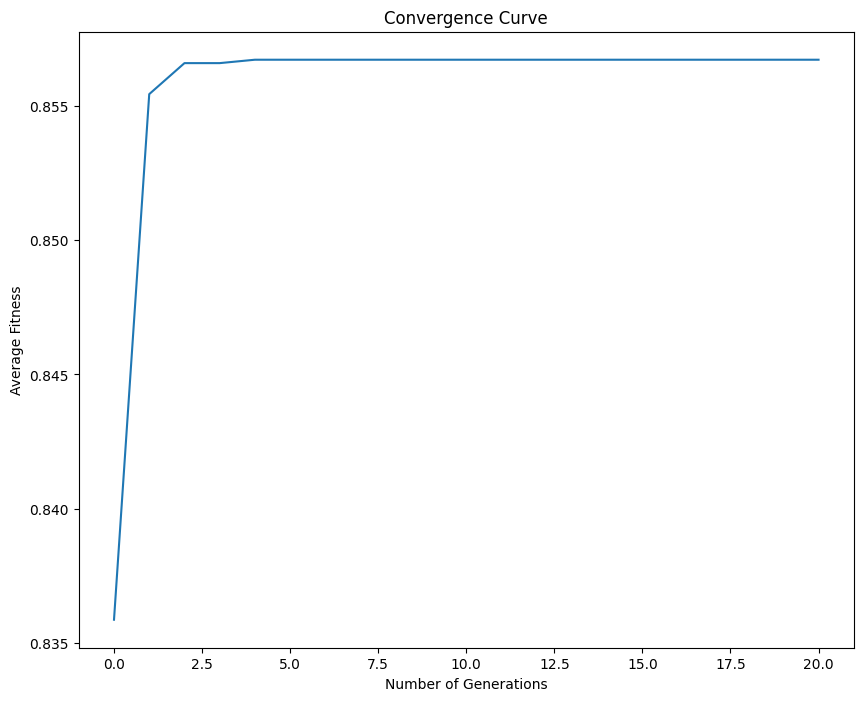


------------- Leader Agent ---------------
Fitness: 0.8571150476932062
Number of Features: 431
----------------------------------------

Processing time: 172.10078406333923 seconds


In [12]:
start_time = time.time()
bba = FS(num_agents=60, max_iter=20, train_data=X_cacao, train_label=y_cacao,save_conv_graph=True)
results_cacao = bba.run()
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

In [13]:
features_selected = []
header = list(X_cacao.columns.values)
for i in range(0, len(header) -1):
  if results_cacao.Leader_agent[i] == 1 :
      features_selected.append(header[i])
print(', '.join(features_selected)) 


1101, 1102, 1103, 1106, 1110, 1112, 1118, 1122, 1128, 1139, 1149, 1156, 1159, 1165, 1170, 1176, 1178, 1179, 1186, 1187, 1188, 1189, 1190, 1192, 1203, 1204, 1205, 1207, 1213, 1214, 1215, 1218, 1221, 1227, 1229, 1236, 1237, 1240, 1242, 1243, 1244, 1245, 1246, 1258, 1262, 1267, 1268, 1269, 1273, 1277, 1280, 1285, 1288, 1298, 1300, 1304, 1307, 1311, 1312, 1315, 1316, 1320, 1325, 1326, 1334, 1335, 1336, 1338, 1344, 1345, 1347, 1348, 1354, 1355, 1357, 1358, 1363, 1366, 1376, 1380, 1383, 1386, 1389, 1390, 1391, 1396, 1399, 1401, 1402, 1404, 1405, 1409, 1411, 1416, 1418, 1419, 1422, 1424, 1429, 1435, 1436, 1456, 1465, 1466, 1471, 1475, 1477, 1480, 1482, 1484, 1485, 1488, 1489, 1490, 1495, 1497, 1499, 1502, 1507, 1515, 1518, 1527, 1528, 1532, 1540, 1541, 1548, 1557, 1566, 1567, 1570, 1572, 1578, 1584, 1586, 1589, 1593, 1601, 1608, 1610, 1612, 1615, 1616, 1619, 1632, 1636, 1641, 1643, 1648, 1650, 1652, 1656, 1658, 1659, 1660, 1667, 1669, 1670, 1680, 1683, 1685, 1692, 1693, 1694, 1700, 1703, 1711

In [14]:
scores = []
kf = KFold(n_splits=5, shuffle=True, random_state =42)
X = X_cacao[features_selected]

for i, (train_index, test_index) in enumerate(kf.split(X.values)):
   
   x_fold_train = X.values[train_index,:]
   y_fold_train = y_cacao.values[train_index]

   x_fold_test =  X.values[test_index,:]
   y_fold_test = y_cacao.values[test_index]
   clf = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
   clf.fit(x_fold_train, y_fold_train)
   y_pred_fold = clf.predict(x_fold_test)
   score = f1_score(y_fold_test, y_pred_fold,average='macro')
   scores.append(score)

res = np.asarray(scores, dtype=np.float32)
print(f"5-CV Cacao OPF mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )

2025-03-30 08:15:36,488 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-30 08:15:36,489 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-30 08:15:36,490 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-30 08:15:36,492 - opfython.core.opf — INFO — Class created.
2025-03-30 08:15:36,493 - opfython.models.supervised — INFO — Class overrided.
2025-03-30 08:15:36,495 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-30 08:15:36,503 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-03-30 08:15:37,414 - opfython.models.supervised — DEBUG — Prototypes: [215, 1, 433, 267, 424, 66, 104, 151, 149, 6, 418, 114, 20, 90, 204, 785, 249, 162, 694, 42, 226, 130, 4, 412, 58, 163, 95, 212, 88, 208, 416, 91, 423, 74, 45, 213, 92, 265, 71, 171, 763, 484, 453, 702, 494, 759, 25, 199, 523, 81, 53, 479, 415, 63, 487, 39, 438, 352, 233, 452, 692, 203, 301, 257, 13, 157, 97, 21

BBA CIS


************    Please enter the values of the following paramters or press newline for using default values    ************


*****************************************************    Thank You    ******************************************************


                          Iteration - 1


Number of agents: 60

------------- Best Agent ---------------
Fitness: 0.958
Number of Features: 3
----------------------------------------

Bat 1 - Fitness: 0.958, Number of Features: 3
Bat 2 - Fitness: 0.958, Number of Features: 3
Bat 3 - Fitness: 0.958, Number of Features: 3
Bat 4 - Fitness: 0.958, Number of Features: 3
Bat 5 - Fitness: 0.958, Number of Features: 3
Bat 6 - Fitness: 0.958, Number of Features: 3
Bat 7 - Fitness: 0.958, Number of Features: 3
Bat 8 - Fitness: 0.958, Number of Features: 3
Bat 9 - Fitness: 0.958, Number of Features: 3
Bat 10 - Fitness: 0.958, Number of Features: 3
Bat 11 - Fitness: 0.958, Number of Features: 3
Bat 12 - Fitness: 0.958, Number of Features: 3
Bat 13

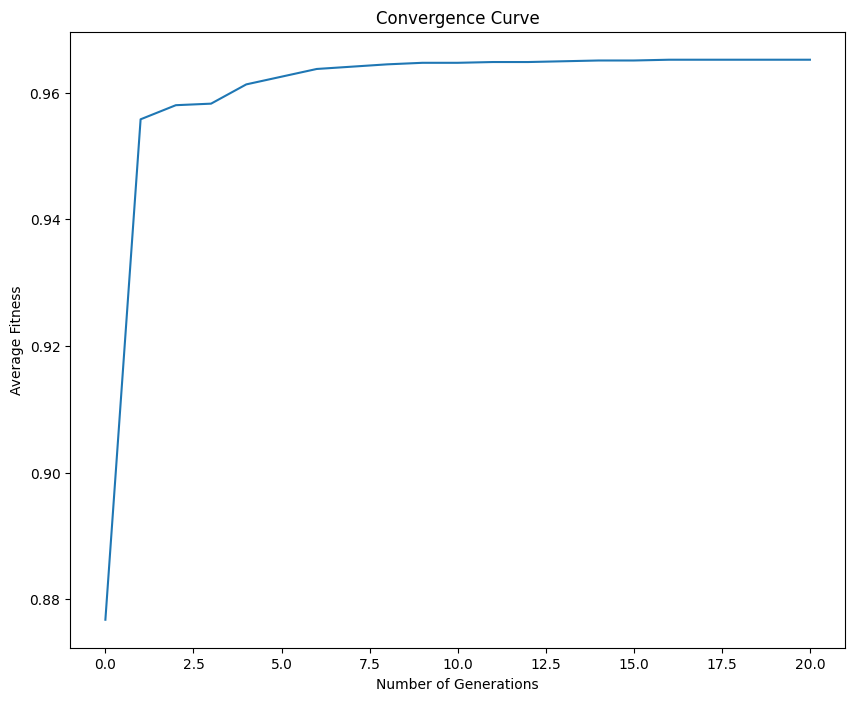


------------- Leader Agent ---------------
Fitness: 0.9653
Number of Features: 2
----------------------------------------

Processing time: 611.8536319732666 seconds


In [24]:
start_time = time.time()
bba = FS(num_agents=60, max_iter=20, train_data=X_cis, train_label=y_cis,save_conv_graph=True)
results_cis = bba.run()
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

In [25]:
features_selected = []
header = list(X_cis.columns.values)
for i in range(0, len(header) -1):
  if results_cis.Leader_agent[i] == 1 :
      features_selected.append(header[i])
print(', '.join(features_selected)) 

X, Y


In [15]:
from sklearn.model_selection import KFold

scores = []
kf = KFold(n_splits=5, shuffle=True, random_state =42)
X = X_cis[['X', 'Y']]

for i, (train_index, test_index) in enumerate(kf.split(X.values)):
   
   x_fold_train = X.values[train_index,:]
   y_fold_train = y_cis.values[train_index]

   x_fold_test =  X.values[test_index,:]
   y_fold_test = y_cis.values[test_index]
   clf = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
   clf.fit(x_fold_train, y_fold_train)
   y_pred_fold = clf.predict(x_fold_test)
   score = f1_score(y_fold_test, y_pred_fold,average='macro')
   scores.append(score)

res = np.asarray(scores, dtype=np.float32)
print(f"5-CV Cacao OPF mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )

2025-03-30 08:16:38,271 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-30 08:16:38,272 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-30 08:16:38,274 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-30 08:16:38,275 - opfython.core.opf — INFO — Class created.
2025-03-30 08:16:38,277 - opfython.models.supervised — INFO — Class overrided.
2025-03-30 08:16:38,279 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-30 08:16:38,331 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-03-30 08:17:31,161 - opfython.models.supervised — DEBUG — Prototypes: [1833, 4241, 2009, 6353, 3167, 520, 5492, 6187, 3335, 4509, 2861, 1002, 761, 5687, 7239, 6634, 4194, 1543, 2705, 5505, 2191, 4083, 6003, 1042, 4598, 427, 1801, 2886, 4952, 1871, 6669, 2557, 2532, 6983, 5489, 1214, 264, 802, 2579, 6897, 7900, 920, 6831, 5593, 6373, 1573, 1329, 5743, 3381, 6195, 2629, 2293, 4131, 